In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
test_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs_mm_vs_ps/quick_run')
run_num = 0
model_name = 'model_auc'

In [3]:
# Download the full samples DF for cross-reference to the results
full_samples_df = pd.read_csv('/data/vision/polina/users/marcusbl/all_data/samples.csv', index_col = 0)

In [4]:
# Downlaod the results dataframe for predictions
downloaded_results_df = pd.read_csv(test_dir / f'run{run_num}' / 'test_info' / f'{model_name}_raw.csv', index_col = 0)

Merge the full_samples DataFrame into the results to get access to more information for each sample

In [5]:
results_df = pd.merge(left = downloaded_results_df, right = full_samples_df, how = 'left', on = ['pdf_num', 'stack_num', 'scan_num', 'path'])
results_df.head(5)

,preds,probs,labels,idxs,pdf_num,stack_num,path,scan_num,mask_path,type,person,person_id,dataset,labeled_scans,num_scans,label
0,1,0.713683,1,0,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,0,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1
1,1,0.955990,1,1,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,1,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1
2,1,0.843210,1,2,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,2,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1
3,1,0.782058,1,3,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,3,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1
4,0,0.347630,1,4,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,4,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1


# Measuring Accuracy vs. Stack Depth

In [6]:
tp_mask = (results_df['labels'] == 1) & (results_df['preds'] == 1)
fp_mask = (results_df['labels'] == 0) & (results_df['preds'] == 0)

In [7]:
min_labeled = results_df['labeled_scans'].apply(ast.literal_eval).apply(min)
max_labeled = results_df['labeled_scans'].apply(ast.literal_eval).apply(max)
results_df['progress'] = (results_df['scan_num'] - min_labeled) / (max_labeled - min_labeled)

In [8]:
results_df

,preds,probs,labels,idxs,pdf_num,stack_num,path,scan_num,mask_path,type,person,person_id,dataset,labeled_scans,num_scans,label,progress
0,1,0.713683,1,0,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,0,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.000000
1,1,0.955990,1,1,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,1,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.030303
2,1,0.843210,1,2,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,2,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.060606
3,1,0.782058,1,3,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,3,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.090909
4,0,0.347630,1,4,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,4,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.121212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,0,0.448813,0,1819,13,18,/data/vision/polina/users/marcusbl/data/anon-0...,33,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00053-7-29-2015,70,R,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",40,0,0.866667
1820,0,0.261542,0,1820,13,18,/data/vision/polina/users/marcusbl/data/anon-0...,34,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00053-7-29-2015,70,R,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",40,0,0.900000
1821,1,0.537753,0,1821,13,18,/data/vision/polina/users/marcusbl/data/anon-0...,35,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00053-7-29-2015,70,R,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",40,0,0.933333
1822,1,0.972334,1,1822,13,18,/data/vision/polina/users/marcusbl/data/anon-0...,36,/data/vision/polina/users/marcusbl/data/anon-0...,NaN,anon-00053-7-29-2015,70,R,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",40,1,0.966667


In [9]:
bins = np.linspace(0, 1, 11)
results_df["bin"] = pd.cut(results_df['progress'], bins = bins, include_lowest=True)
results_df['bin'].value_counts()

bin
(-0.001, 0.1]    217
(0.9, 1.0]       204
(0.3, 0.4]       184
(0.4, 0.5]       181
(0.7, 0.8]       178
(0.6, 0.7]       178
(0.1, 0.2]       175
(0.8, 0.9]       170
(0.2, 0.3]       169
(0.5, 0.6]       168
Name: count, dtype: int64

In [21]:
results_df['bin'].cat.categories

IntervalIndex([(-0.001, 0.1],    (0.1, 0.2],    (0.2, 0.3],    (0.3, 0.4],
                  (0.4, 0.5],    (0.5, 0.6],    (0.6, 0.7],    (0.7, 0.8],
                  (0.8, 0.9],    (0.9, 1.0]],
              dtype='interval[float64, right]')

In [10]:
pos_frac_by_bin = results_df.groupby("bin", observed=True)['labels'].mean()

tpr_by_bin = (
    results_df
    .groupby("bin", observed=True)
    .apply(lambda g: ((g["labels"] == 1) & (g["preds"] == 1)).sum()
                     / (g["labels"] == 1).sum(),
           include_groups=False)
)

fpr_by_bin = (
    results_df.groupby("bin", observed=True)
      .apply(lambda g: ((g["labels"] == 0) & (g["preds"] == 1)).sum()
                       / (g["labels"] == 0).sum(), include_groups=False)
)


Text(0.5, 1.0, 'TPR vs. Stack Progress')

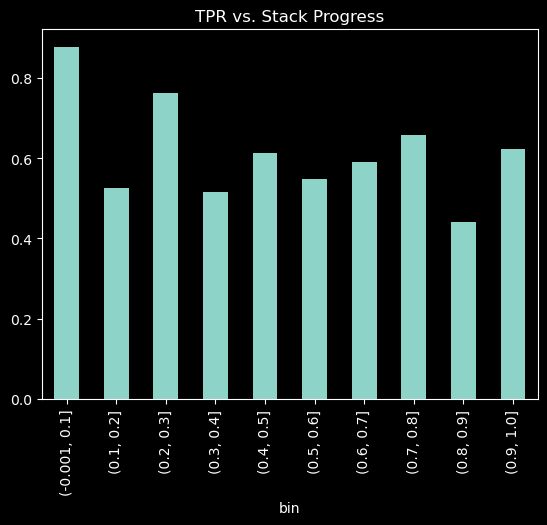

In [11]:
tpr_by_bin.plot(kind='bar')
plt.title("TPR vs. Stack Progress")

Text(0.5, 1.0, 'FPR vs. Stack Progress')

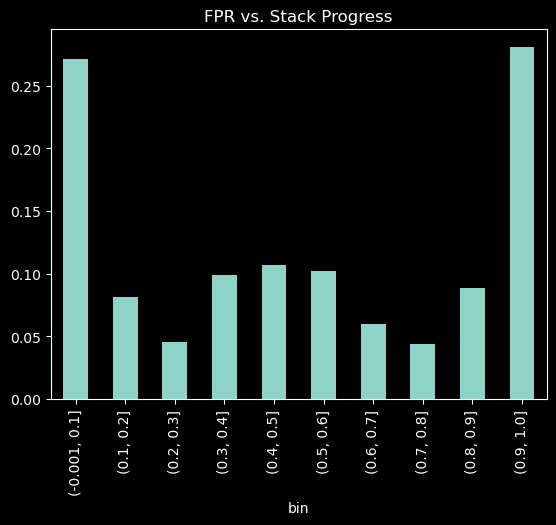

In [12]:
fpr_by_bin.plot(kind='bar')
plt.title("FPR vs. Stack Progress")

<Axes: xlabel='bin'>

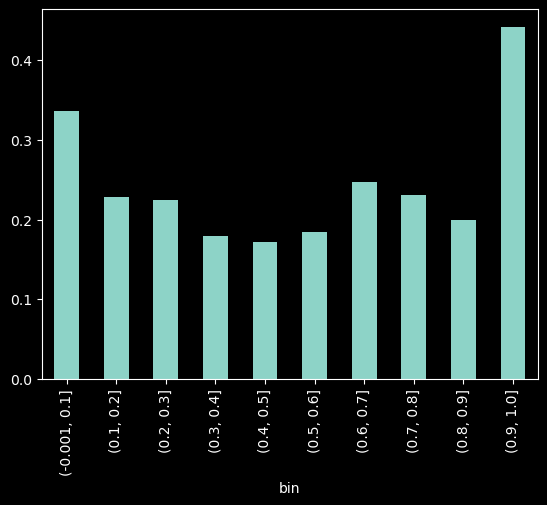

In [13]:
pos_frac_by_bin.plot(kind='bar')